In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load saved data
close_prices = pd.read_csv('../data/stock_close_prices.csv', 
                           index_col='Date', 
                           parse_dates=True)

print("Data loaded:", close_prices.shape)
close_prices.head()

Data loaded: (1760, 4)


,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2019-01-02,37.503731,76.956497,52.301727,94.397156
2019-01-03,33.768074,75.014000,50.853203,90.924477
2019-01-04,35.209610,78.769501,53.461639,95.153305
2019-01-07,35.131248,81.475502,53.355022,95.274643
2019-01-08,35.800953,82.829002,53.823654,95.965462


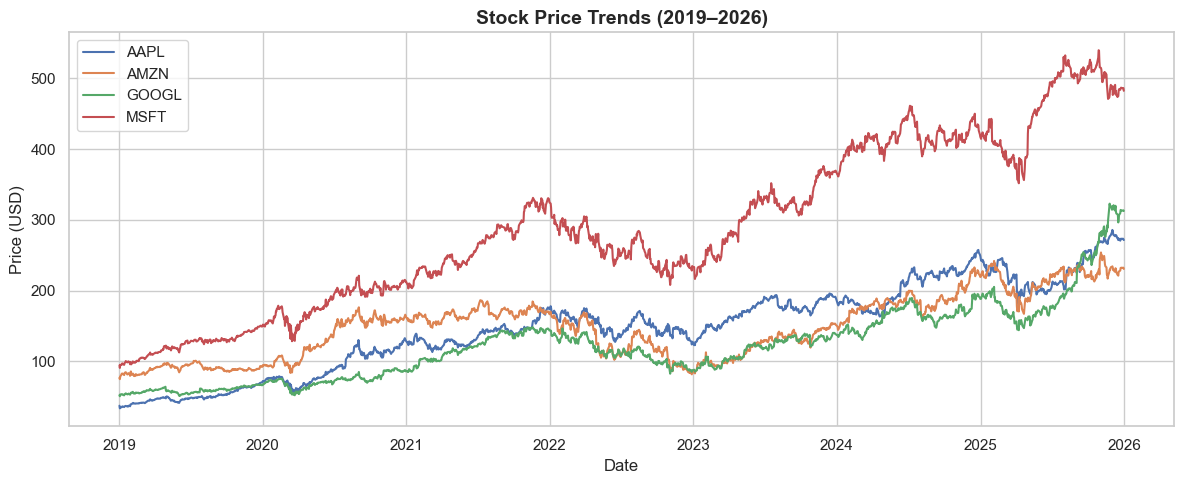

In [2]:
fig, ax = plt.subplots()

for ticker in close_prices.columns:
    ax.plot(close_prices.index, 
            close_prices[ticker], 
            label=ticker,
            linewidth=1.5)

ax.set_title('Stock Price Trends (2019–2026)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/chart1_price_trends.png', dpi=150)
plt.show()

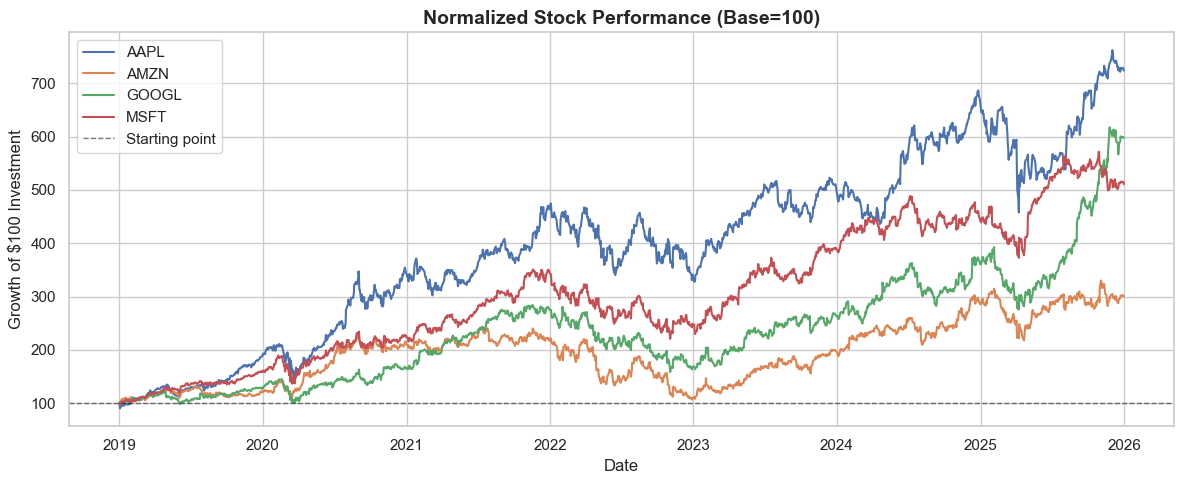

In [3]:
# Normalize: set all stocks to 100 at start date
normalized = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots()

for ticker in normalized.columns:
    ax.plot(normalized.index,
            normalized[ticker],
            label=ticker,
            linewidth=1.5)

# Add reference line at 100 (breakeven)
ax.axhline(y=100, color='black', linestyle='--', 
           linewidth=1, alpha=0.5, label='Starting point')

ax.set_title('Normalized Stock Performance (Base=100)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $100 Investment')
ax.legend()
plt.tight_layout()
plt.savefig('../images/chart2_normalized_performance.png', dpi=150)
plt.show()

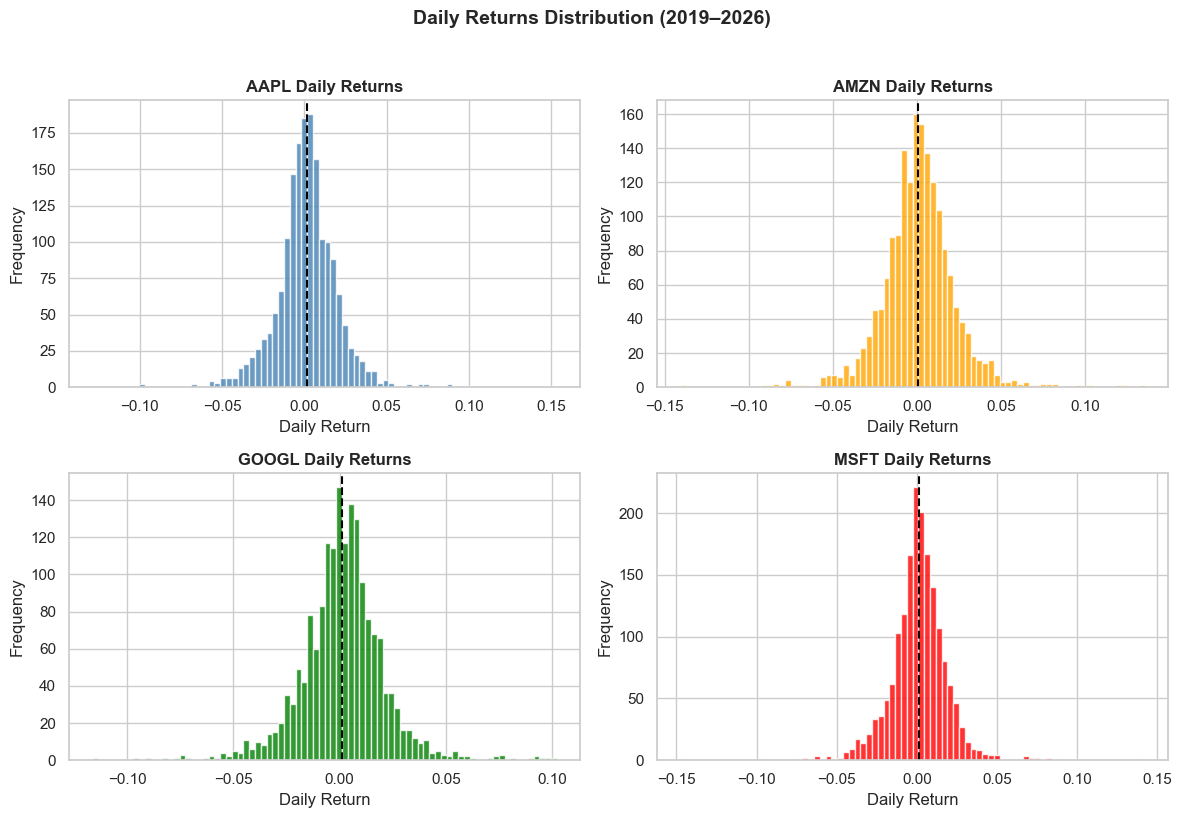

In [4]:
# Calculate daily percentage returns
daily_returns = close_prices.pct_change().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ['steelblue', 'orange', 'green', 'red']

for i, ticker in enumerate(daily_returns.columns):
    axes[i].hist(daily_returns[ticker], 
                 bins=80, 
                 color=colors[i],
                 edgecolor='white',
                 alpha=0.8)
    axes[i].axvline(daily_returns[ticker].mean(),
                    color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{ticker} Daily Returns', fontweight='bold')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Daily Returns Distribution (2019–2026)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/chart3_daily_returns.png', dpi=150)
plt.show()

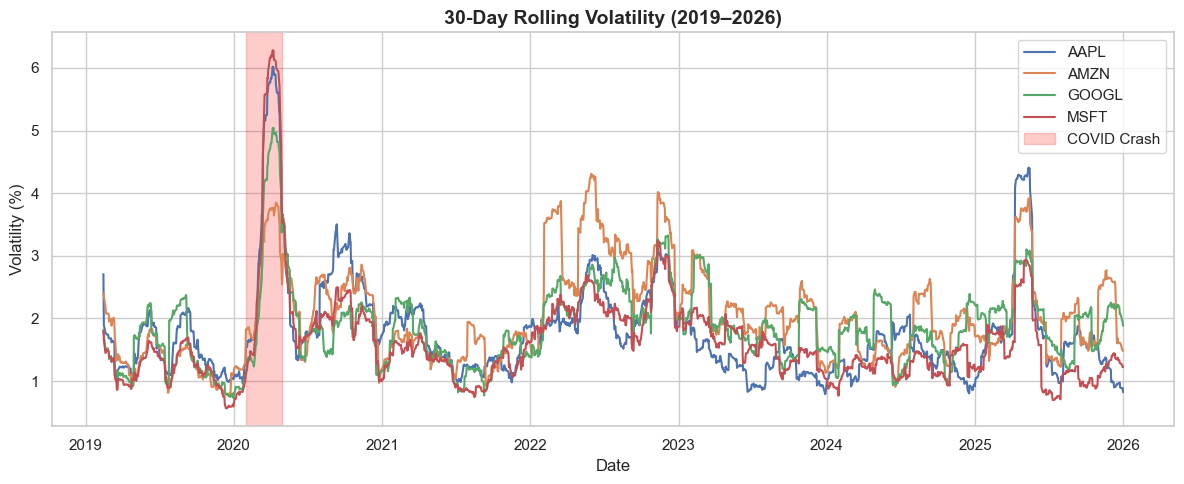

In [5]:
# Calculate 30-day rolling volatility
rolling_vol = daily_returns.rolling(window=30).std() * 100

fig, ax = plt.subplots()

for ticker in rolling_vol.columns:
    ax.plot(rolling_vol.index,
            rolling_vol[ticker],
            label=ticker,
            linewidth=1.5)

# Highlight COVID crash period
ax.axvspan('2020-02-01', '2020-04-30',
           alpha=0.2, color='red',
           label='COVID Crash')

ax.set_title('30-Day Rolling Volatility (2019–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/chart4_rolling_volatility.png', dpi=150)
plt.show()

## Analysis Summary & Investment Insights

### Finding 1 — Raw Prices Are Misleading
MSFT appeared to be the top performer based on absolute price.
Normalization revealed AAPL was the actual best performer (+630%).

### Finding 2 — AAPL: Best Risk-Adjusted Return
AAPL delivered the highest normalized return (+630%) with 
relatively low daily volatility — the ideal combination for investors.

### Finding 3 — AMZN: High Risk, Low Reward
Amazon showed the widest daily return distribution (most volatile)
but delivered the weakest 5-year return (+200%). 
Worst risk-adjusted performance of the four.

### Finding 4 — Volatility Spikes Are Market-Wide Events
COVID crash (March 2020) caused simultaneous volatility spikes 
across all 4 stocks, confirming high correlation during market crises.
Secondary spikes visible in 2022 (rate hikes) and 2025 (macro uncertainty).